In [1]:
from models.rvm_tf import RecurrentWorldModel
import torch
import yaml
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
with open("/home/rvm/configs/train_ema.yaml", "r") as f:
    config = yaml.safe_load(f)
model = RecurrentWorldModel(**config.get("model", {}))

/root/miniconda3/envs/gssl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading the vision encoder from facebook/dinov2-with-registers-small


Loading weights: 100%|██████████| 224/224 [00:00<00:00, 1936.24it/s]


In [3]:
checkpoint = torch.load("/home/rvm/checkpoints/checkpoints_rwm/exp_1788015780.3685207/model_epoch1_step2100.pth", weights_only=False)
model.load_state_dict(checkpoint['model'])

<All keys matched successfully>

In [6]:
video_path = '/home/rvm/src/c99d46743f5a5760705af190faa69e1bacae4b788c1e44c901c47b78de7ab7cc.mp4'
# video_path = '/home/ego4d/data/v2/video_540ss/efe779fd-51bb-4de7-b4a1-332a594d14cb.mp4'
# video_path = '/home/rvm/src/cycling.mp4'
import cv2
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Cannot open video")

frames = []
while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (252, 252))
    frame = frame/255.0
    frames.append(frame)    

print(len(frames))
stride = 10
frames = frames[int(0.3 * len(frames)):]
frames = frames[::stride]
print(len(frames))

636
45


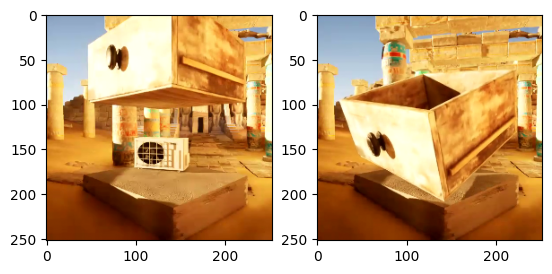

In [8]:
plt.subplot(1, 2, 1)
plt.imshow(frames[0])
plt.subplot(1, 2, 2)
plt.imshow(frames[9])

In [9]:
frames[0].shape

(252, 252, 3)

In [10]:
from tqdm import tqdm
import torch
import torch.nn.functional as F

stride = 35  # anywhere around 30-40

losses = []

for i in tqdm(range(0, len(frames) - stride, stride)):
    j = i + stride

    frame1 = torch.tensor(frames[i], dtype=torch.float32).unsqueeze(0).permute(0, 3, 1, 2)
    frame2 = torch.tensor(frames[j], dtype=torch.float32).unsqueeze(0).permute(0, 3, 1, 2)

    feat1 = model.encode(frame1)
    feat2 = model.encode(frame2)

    loss = F.smooth_l1_loss(feat1, feat2, beta = 0.1)
    losses.append(loss.item())

average_loss = sum(losses) / len(losses)

print("Number of pairs:", len(losses))
print("Average loss:", average_loss)

100%|██████████| 1/1 [00:00<00:00,  5.13it/s]

Number of pairs: 1
Average loss: 0.8024349212646484


In [11]:
from tqdm import tqdm
import torch
import torch.nn.functional as F

stride = 35      # distance between the two frames
sample_step = 5  # how frequently we sample starting frames

losses = []

for i in tqdm(range(0, len(frames) - stride, sample_step)):
    j = i + stride

    frame1 = torch.tensor(frames[i], dtype=torch.float32).unsqueeze(0).permute(0, 3, 1, 2)
    frame2 = torch.tensor(frames[j], dtype=torch.float32).unsqueeze(0).permute(0, 3, 1, 2)

    feat1 = model.encode(frame1)
    feat2 = model.encode(frame2)
    # print(feat1.shape)

    loss = F.smooth_l1_loss(feat1[:, 1:, :], feat2[:, 1:, :], beta = 0.1)
    losses.append(loss.item())

average_loss = sum(losses) / len(losses)

print("Number of pairs:", len(losses))
print("Average loss:", average_loss)

100%|██████████| 2/2 [00:00<00:00,  8.83it/s]

Number of pairs: 2
Average loss: 0.6987661421298981


(array([ 9.,  9., 28., 37., 52., 90., 62., 95., 44., 14.]),
 array([0.42203084, 0.4991589 , 0.57628696, 0.65341502, 0.73054308,
        0.80767114, 0.88479921, 0.96192727, 1.03905533, 1.11618339,
        1.19331145]),
 <BarContainer object of 10 artists>)

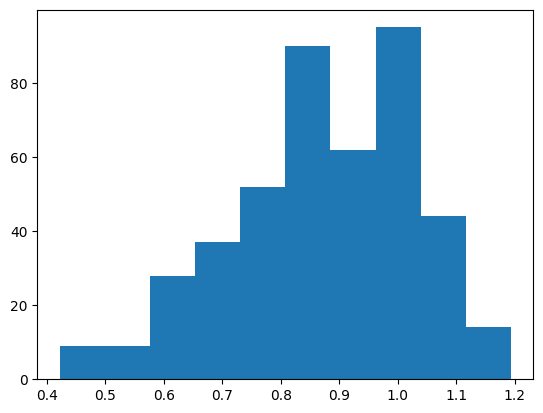

In [9]:
plt.hist(losses)

In [ ]:
# device = "cuda"
# model = model.to(device)
# model.eval()

# C = 10                          # how many leading frames to use as context
# # S = len(frames) - C            # how many future frames to roll out
# S = 6
# context = torch.tensor(np.stack(frames[:C]), dtype=torch.float32)   # (C, H, W, 3)
# context = context.permute(0, 3, 1, 2).unsqueeze(0).to(device)       # (B=1, C, 3, H, W)

# # your frames are already subsampled by stride=10, so consecutive frames
# # are 1 "unit" apart -- keep context_times/gaps in that same unit
# context_times = torch.arange(C, dtype=torch.float32).unsqueeze(0).to(device)  # (1, C)
# gaps = torch.ones(S, dtype=torch.float32).to(device)                           # (S,)

# with torch.no_grad():
#     out = model.rollout(
#         context=context,
#         gaps=gaps,
#         context_times=context_times,
#     )

# pred = out["pred"]              # (B, S, n_tok, D) — feature-space predictions either way
# recon = out.get("recon")        # (B, S, 3, H, W) — only present if model.objective == "pixel"


In [14]:
# indices = np.arange(10)
# np.random.shuffle(indices)

# context_frames = np.stack(frames[:10])[indices]
# indices

In [15]:


device = "cuda"
model = model.to(device)
model.eval()

C = 5                          # how many leading frames to use as context
S = 5                            # how many frames to predict (needs ground truth)
indices = np.arange(C)
# np.random.shuffle(indices)
context_frames = np.stack(frames[:C])[indices]

context = torch.tensor(context_frames, dtype=torch.float32)      # (C, H, W, 3)
context = context.permute(0, 3, 1, 2).unsqueeze(0).to(device)          # (B=1, C, 3, H, W)

indices = np.arange(S)
# np.random.shuffle(indices)
target_frames = np.stack(frames[C:C+S])[indices]
targets = torch.tensor(target_frames, dtype=torch.float32)  # (S, H, W, 3)
targets = targets.permute(0, 3, 1, 2).unsqueeze(0).to(device)           # (B=1, S, 3, H, W)

# same 1-unit-per-frame convention; target_times continues context_times' clock
context_times = torch.arange(C, dtype=torch.float32).unsqueeze(0).to(device)         # (1, C)
target_times = torch.arange(C, C + S, dtype=torch.float32).unsqueeze(0).to(device)   # (1, S)

# gaps[i] = target_times[i] - target_times[i-1] (or - context_times[-1] for i=0);
# since both clocks step by 1 per sampled frame here, every gap is 1.0
gaps = torch.ones(S, dtype=torch.float32, device=device)   # (S,)

with torch.no_grad():
    out = model.rollout(
        context=context,              # (B, C, 3, H, W)
        gaps=gaps,                    # (S,) time gaps between predicted steps
        context_times=context_times,  # (B, C)
    )

preds = out["pred"]              # (B, S, n_tok, D) -- repr_head output, one per predicted step
context_memory = out["context_memory"]   # (B, C+S, n_tok, D) core states, context + rolled-out steps
# context_state  = out["state"]            # (B, n_tok, D) final GRU state
context_feats = out['context_feat']

# recon_tf = out_tf["recon"]      # (B, S, 3, H, W)
print(preds.shape)

torch.Size([1, 5, 325, 384])


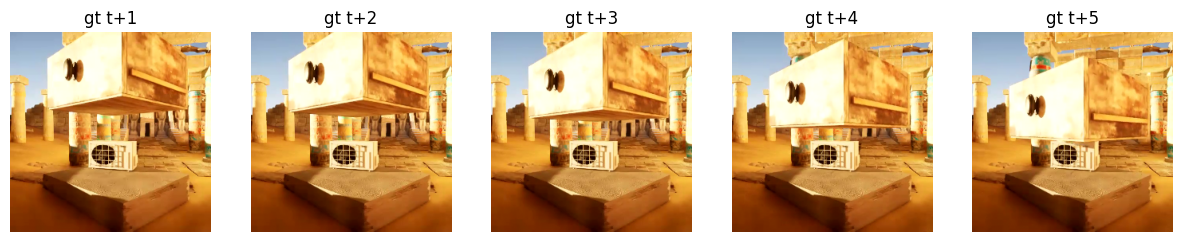

In [16]:
gt = context_frames
fig, axes = plt.subplots(1, C, figsize=(3 * S, 6))
for s in range(C):
    axes[s].imshow(gt[s])
    axes[s].set_title(f"gt t+{s+1}")
    axes[s].axis("off")


frame 0: explained variance = [0.25  0.17  0.121]  (sum 0.541)
frame 1: explained variance = [0.261 0.177 0.123]  (sum 0.561)
frame 2: explained variance = [0.269 0.183 0.124]  (sum 0.576)
frame 3: explained variance = [0.274 0.187 0.123]  (sum 0.585)
frame 4: explained variance = [0.278 0.19  0.123]  (sum 0.591)


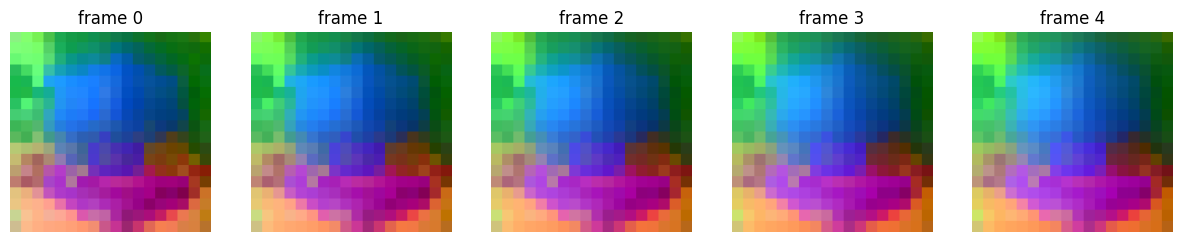

In [17]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_feats = pca_per_frame(preds[:, :, 1:, :])
feats_pca_image = show(pca_feats)

frame 0: explained variance = [0.183 0.132 0.101]  (sum 0.416)
frame 1: explained variance = [0.192 0.127 0.101]  (sum 0.421)
frame 2: explained variance = [0.194 0.127 0.105]  (sum 0.426)
frame 3: explained variance = [0.18  0.134 0.103]  (sum 0.417)
frame 4: explained variance = [0.173 0.139 0.103]  (sum 0.415)


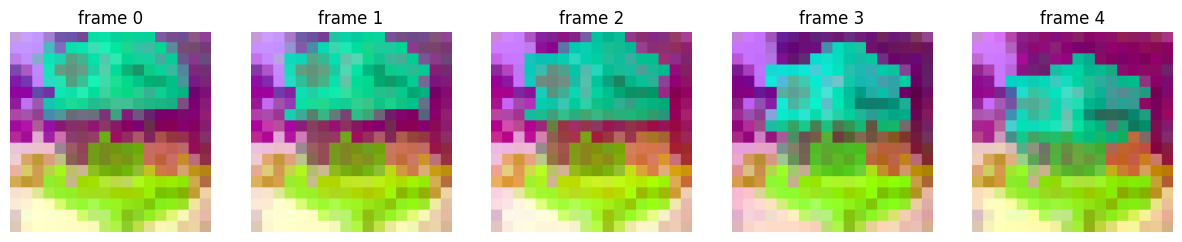

In [19]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_feats = pca_per_frame(context_feats[:, :C, 1:, :])
feats_pca_image = show(pca_feats)

frame 0: explained variance = [0.184 0.126 0.099]  (sum 0.409)
frame 1: explained variance = [0.188 0.123 0.099]  (sum 0.411)
frame 2: explained variance = [0.194 0.124 0.101]  (sum 0.419)
frame 3: explained variance = [0.183 0.129 0.1  ]  (sum 0.413)
frame 4: explained variance = [0.181 0.132 0.101]  (sum 0.413)


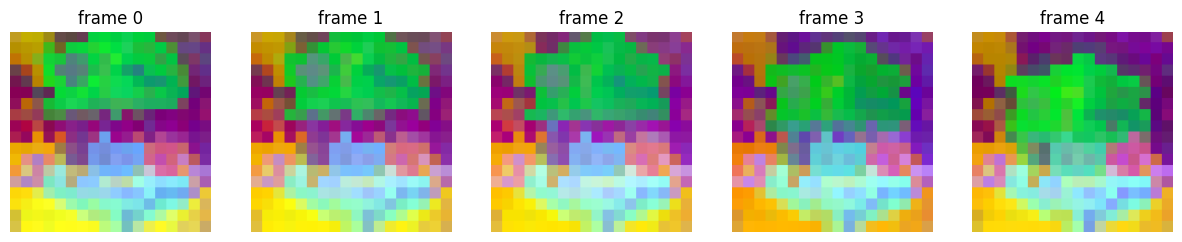

In [20]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_memory = pca_per_frame(context_memory[:, :C, 1:, :])
memory_pca_image = show(pca_memory)

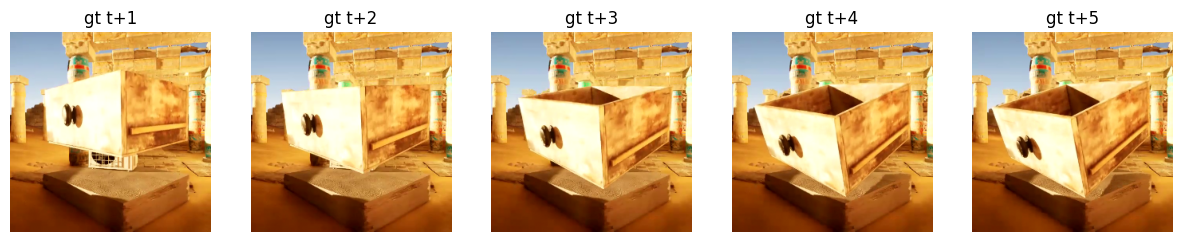

In [21]:
gt = target_frames
fig, axes = plt.subplots(1, S, figsize=(3 * S, 6))
for s in range(S):
    axes[s].imshow(gt[s])
    axes[s].set_title(f"gt t+{s+1}")
    axes[s].axis("off")


frame 0: explained variance = [0.175 0.143 0.102]  (sum 0.420)
frame 1: explained variance = [0.172 0.15  0.092]  (sum 0.414)
frame 2: explained variance = [0.234 0.136 0.086]  (sum 0.457)
frame 3: explained variance = [0.25  0.134 0.081]  (sum 0.466)
frame 4: explained variance = [0.244 0.136 0.082]  (sum 0.462)


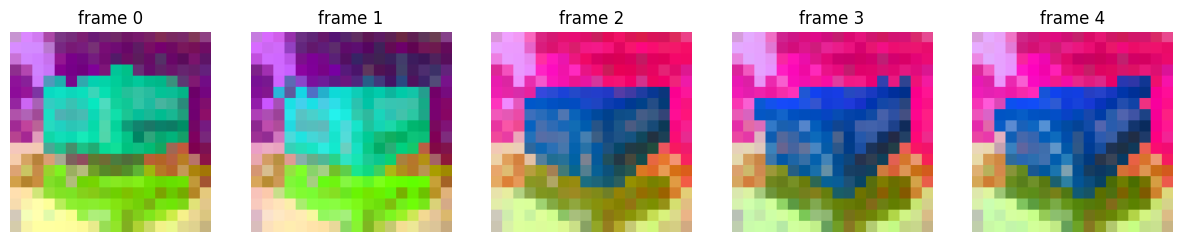

In [22]:
bs, N = targets.shape[:2]
img = targets.shape[2:]
target_feats = model.encode(targets.view(bs * N, *img)).unsqueeze(0)
# print(target_feats.shape)

pca_target_feats = pca_per_frame(target_feats[:, :, 1:, :])
target_feats_pca_image = show(pca_target_feats)
# plt.title("target features (dino)")

frame 0: explained variance = [0.233 0.135 0.11 ]  (sum 0.478)
frame 1: explained variance = [0.255 0.135 0.114]  (sum 0.504)
frame 2: explained variance = [0.268 0.136 0.117]  (sum 0.521)
frame 3: explained variance = [0.275 0.137 0.12 ]  (sum 0.532)
frame 4: explained variance = [0.28  0.14  0.121]  (sum 0.541)


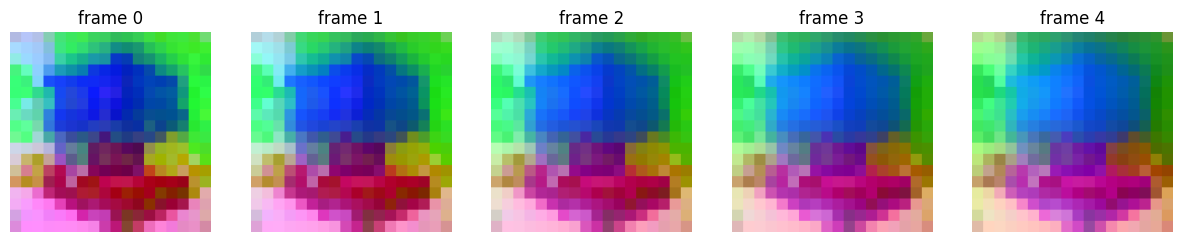

In [23]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_memory = pca_per_frame(context_memory[:, C:, 1:, :])
memory_pca_image = show(pca_memory)

frame 0: explained variance = [0.25  0.17  0.121]  (sum 0.541)
frame 1: explained variance = [0.261 0.177 0.123]  (sum 0.561)
frame 2: explained variance = [0.269 0.183 0.124]  (sum 0.576)
frame 3: explained variance = [0.274 0.187 0.123]  (sum 0.585)
frame 4: explained variance = [0.278 0.19  0.123]  (sum 0.591)


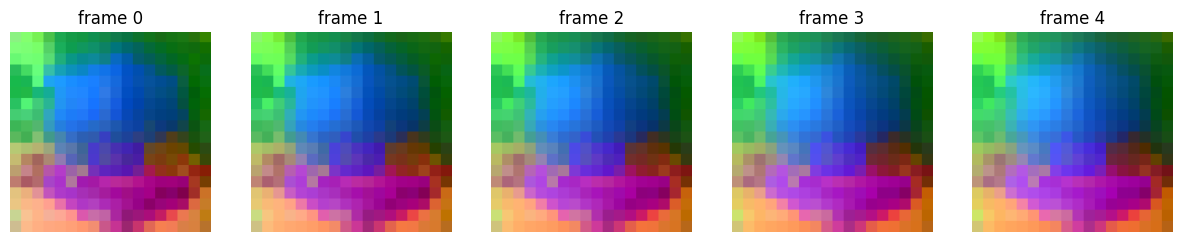

In [24]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_predictions = pca_per_frame(preds[:, :, 1:, :])
pred_pca_image = show(pca_predictions)

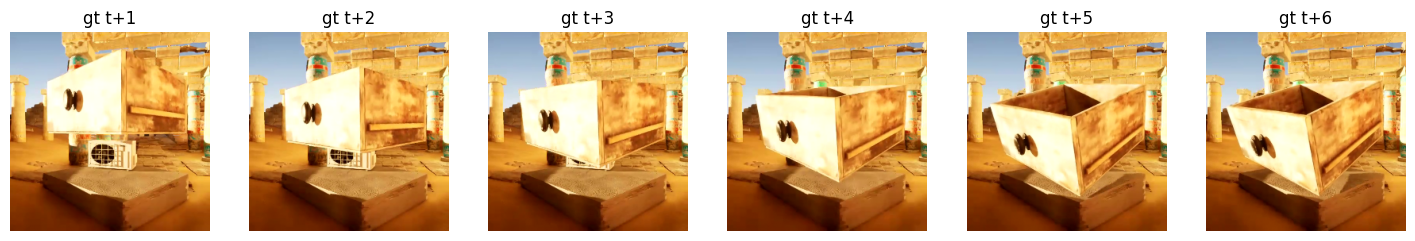

In [30]:
gt = target_frames
fig, axes = plt.subplots(1, S, figsize=(3 * S, 6))
for s in range(S):
    axes[s].imshow(gt[s])
    axes[s].set_title(f"gt t+{s+1}")
    axes[s].axis("off")


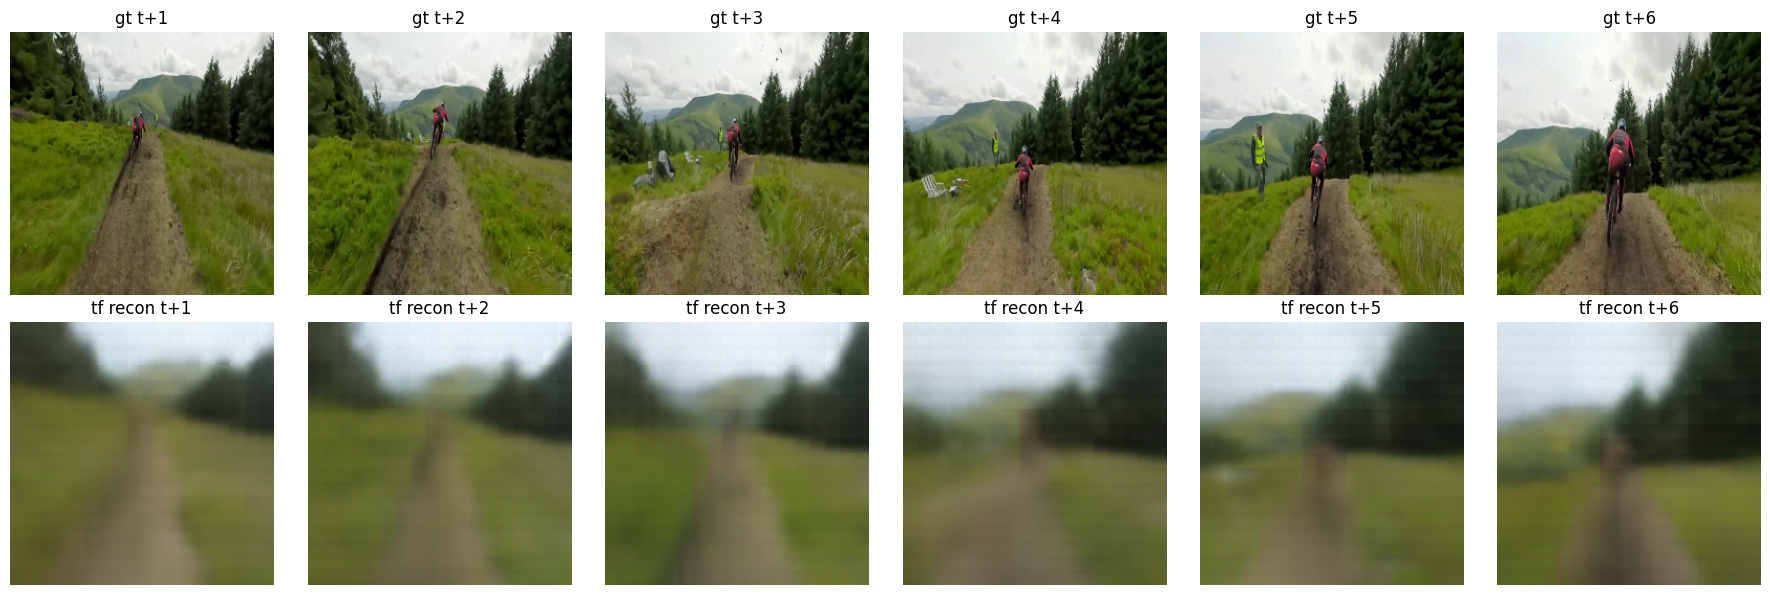

In [ ]:
# # gt = np.stack(frames[C:C + S])                                  # (S, H, W, 3), in [0,1]
# gt = target_frames
# recon_np = recon_tf[0].detach().cpu().permute(0, 2, 3, 1).numpy()
# recon_np = np.clip(recon_np, 0.0, 1.0)

# fig, axes = plt.subplots(2, S, figsize=(3 * S, 6))
# for s in range(S):
#     axes[0, s].imshow(gt[s])
#     axes[0, s].set_title(f"gt t+{s+1}")
#     axes[0, s].axis("off")

#     axes[1, s].imshow(recon_np[s])
#     axes[1, s].set_title(f"tf recon t+{s+1}")
#     axes[1, s].axis("off")

# plt.tight_layout()
# plt.show()


In [9]:
import torch.nn.functional as F

r = recon_tf                                                   # (1, S, 3, H, W)
gt = targets                                                   # (1, S, 3, H, W), shuffled order
prev = torch.cat([context[:, -1:], targets[:, :-1]], dim=1)    # what the core saw one step earlier
mean = gt.mean(dim=1, keepdim=True).expand_as(gt)

def per_step(a, b):                # (S,) MSE, one value per predicted step
    return (a - b).pow(2).flatten(2).mean(-1)[0]

print(f"{'':6} {'all':>8}  " + "  ".join(f"s{i+1:<5}" for i in range(S)))
for name, ref in [("gt", gt), ("prev", prev), ("mean", mean)]:
    ps = per_step(r, ref)
    print(f"{name:6} {F.mse_loss(r, ref).item():8.5f}  " + "  ".join(f"{v:6.5f}" for v in ps))

# does the output move at all as s changes?
print("recon var across s:", r.std(dim=1).mean().item())
print("gt    var across s:", gt.std(dim=1).mean().item())

            all  s1      s2      s3      s4      s5      s6    
gt      0.01760  0.01506  0.02076  0.03099  0.01361  0.01311  0.01206
prev    0.01157  0.01630  0.01490  0.01347  0.01008  0.00773  0.00692
mean    0.02050  0.04255  0.03113  0.01934  0.00873  0.00949  0.01176
recon var across s: 0.0936046913266182
gt    var across s: 0.12576426565647125


In [10]:
out_tf.keys()

dict_keys(['recon', 'target_feat', 'context_memory', 'context_feat', 'state'])

In [11]:
context_feat, context_memory = out_tf['context_feat'].cpu().squeeze(0).numpy(), out_tf['context_memory'].cpu().squeeze(0).numpy()

In [12]:
context_feat.shape

(10, 325, 384)

frame 0: explained variance = [0.186 0.174 0.094]  (sum 0.454)
frame 1: explained variance = [0.202 0.155 0.088]  (sum 0.445)
frame 2: explained variance = [0.206 0.15  0.097]  (sum 0.453)
frame 3: explained variance = [0.213 0.143 0.097]  (sum 0.454)
frame 4: explained variance = [0.249 0.143 0.087]  (sum 0.479)
frame 5: explained variance = [0.263 0.155 0.089]  (sum 0.506)
frame 6: explained variance = [0.252 0.137 0.079]  (sum 0.468)
frame 7: explained variance = [0.243 0.145 0.091]  (sum 0.478)
frame 8: explained variance = [0.249 0.152 0.091]  (sum 0.492)
frame 9: explained variance = [0.247 0.176 0.093]  (sum 0.516)
frame 0: explained variance = [0.203 0.162 0.096]  (sum 0.462)
frame 1: explained variance = [0.199 0.163 0.103]  (sum 0.465)
frame 2: explained variance = [0.229 0.16  0.099]  (sum 0.489)
frame 3: explained variance = [0.254 0.134 0.101]  (sum 0.489)
frame 4: explained variance = [0.269 0.158 0.089]  (sum 0.516)
frame 5: explained variance = [0.275 0.134 0.1  ]  (sum

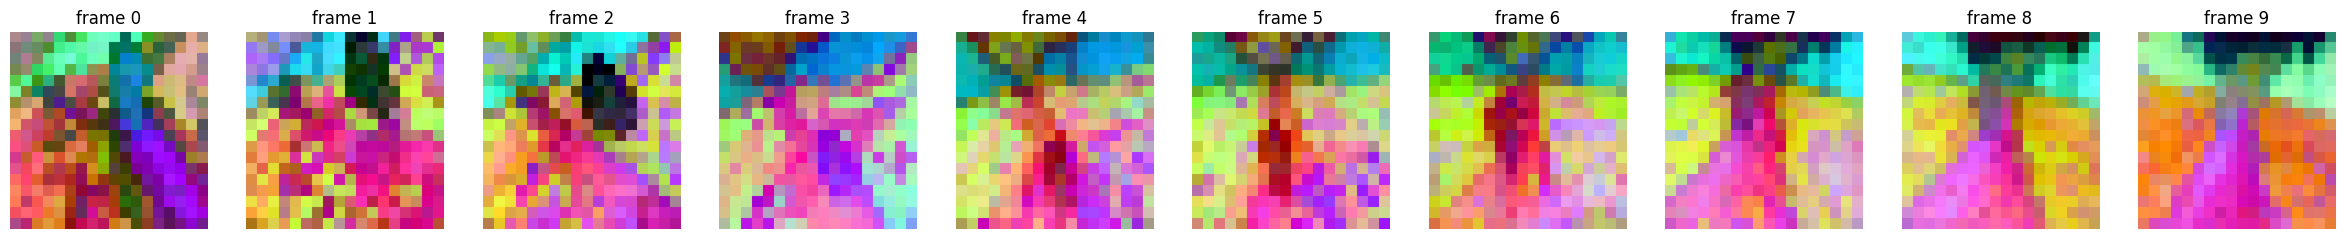

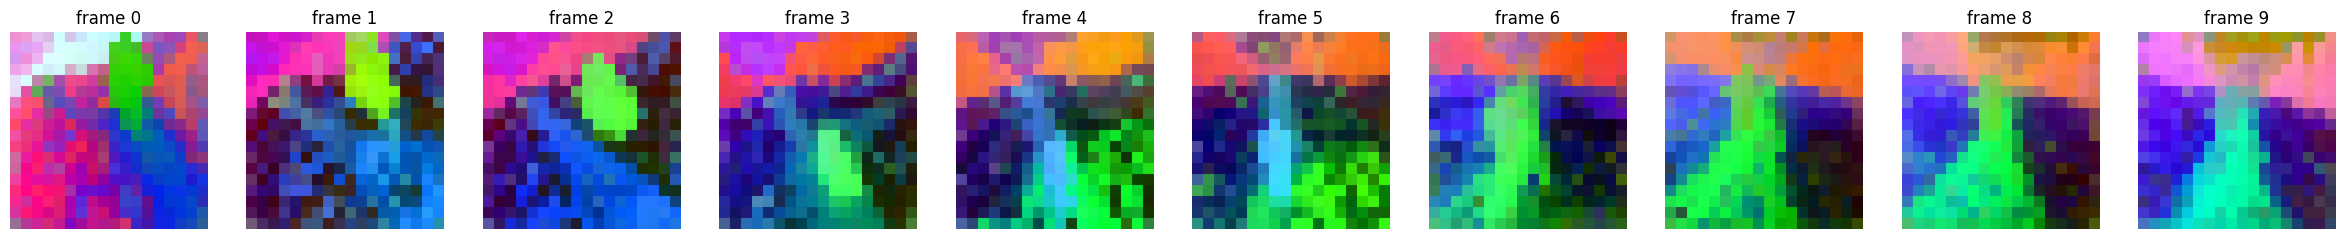

In [13]:
from pca_vis import pca_per_frame, show
mem_pc, con_pc = pca_per_frame(context_memory[:C, 1:, :]), pca_per_frame(context_feat[:, 1:, :])
mem_pc_img, con_pc_img = show(mem_pc), show(con_pc)

In [14]:
context_feat.shape, context_memory.shape

((10, 325, 384), (16, 325, 384))

In [15]:
feats = out_tf["context_feat"]        # (B, C, n_tok, D)
mem   = out_tf["context_memory"]      # (B, C+S, n_tok, D) -- context steps first
C     = feats.shape[1]
m     = mem[:, :C]                    # align to the context frames only

same = torch.cosine_similarity(m, feats, dim=-1).mean(dim=(0, 2))          # (C,)
prev = torch.cosine_similarity(m[:, 1:], feats[:, :-1], dim=-1).mean(dim=(0, 2))  # (C-1,)

print("t   cos(mem_t, feat_t)   cos(mem_t, feat_{t-1})")
for t in range(C):
    p = f"{prev[t-1]:.3f}" if t > 0 else "  -  "
    print(f"{t:<3} {same[t]:>12.3f} {p:>18}")

print(f"\nmean same={same.mean():.3f}  prev={prev.mean():.3f}")

t   cos(mem_t, feat_t)   cos(mem_t, feat_{t-1})
0          0.614                -  
1          0.631              0.523
2          0.626              0.517
3          0.610              0.491
4          0.606              0.502
5          0.613              0.500
6          0.618              0.518
7          0.593              0.507
8          0.612              0.519
9          0.595              0.520

mean same=0.612  prev=0.511
